In [7]:
import pandas as pd

# Load the GPU sales dataset
file_path = r"C:\Users\Sakthi\Data Visualization Techniques\nvidia_gpu_sales_synthetic_2026.csv"
df = pd.read_csv(file_path)

# Display dataset dimensions and preview initial rows
print(f"Dataset Shape: {df.shape}")
print(df.head())

Dataset Shape: (7000, 17)
   sale_id   sale_date          gpu_model       gpu_family  launch_year  \
0        1  2024-01-12           RTX 4090  Consumer Gaming         2022   
1        2  2024-01-18  RTX 4070 Ti Super  Consumer Gaming         2024   
2        3  2024-01-20     RTX 4080 Super  Consumer Gaming         2024   
3        4  2024-02-05           H100 SXM   Data Center AI         2022   
4        5  2024-02-16           H100 SXM   Data Center AI         2022   

                    region          sales_channel  customer_segment  \
0  Asia-Pacific (ex-China)           Retail/Etail            Gaming   
1  Asia-Pacific (ex-China)  System Integrator/OEM  Content Creation   
2            North America           Retail/Etail            Gaming   
3  Asia-Pacific (ex-China)      Direct Enterprise     Crypto Mining   
4                   Europe         Cloud Provider     Crypto Mining   

   units_sold  msrp_usd  avg_street_price_usd  price_premium_pct stock_status  \
0           8  

In [8]:
# Summary metrics for sales, revenue, and customer satisfaction
summary_stats = df[["units_sold", "revenue_usd", "customer_satisfaction_score", "price_premium_pct"]].describe()
print(summary_stats)

        units_sold   revenue_usd  customer_satisfaction_score  \
count  7000.000000  7.000000e+03                  7000.000000   
mean     21.674143  5.658006e+04                     4.428286   
std      12.928136  9.996269e+04                     0.608437   
min       1.000000  1.393130e+03                     1.500000   
25%      12.000000  1.555133e+04                     4.000000   
50%      20.000000  2.534293e+04                     4.500000   
75%      29.000000  4.670657e+04                     5.000000   
max     104.000000  1.225726e+06                     5.000000   

       price_premium_pct  
count        7000.000000  
mean           15.010536  
std            14.348016  
min             0.000000  
25%             4.560000  
50%             8.850000  
75%            21.352500  
max            98.460000  


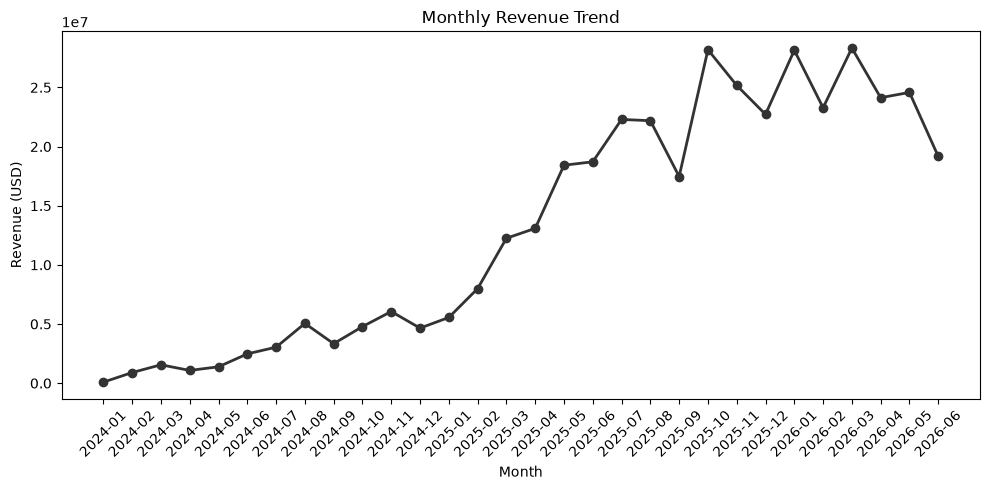

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data and prepare month_year column directly
file_path = r"C:\Users\Sakthi\Data Visualization Techniques\nvidia_gpu_sales_synthetic_2026.csv"
df = pd.read_csv(file_path)

df['sale_date'] = pd.to_datetime(df['sale_date'])
df['month_year'] = df['sale_date'].dt.to_period('M').astype(str)

# Aggregate total revenue by month
monthly_revenue = df.groupby('month_year')['revenue_usd'].sum().reset_index()

# Plot line chart
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue['month_year'], monthly_revenue['revenue_usd'], marker='o', color='#333333', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# Aggregate total revenue and units sold by GPU family
family_metrics = df.groupby("gpu_family")[["units_sold", "revenue_usd"]].sum().reset_index()
print(family_metrics)

        gpu_family  units_sold   revenue_usd
0  Consumer Gaming      144692  1.629497e+08
1   Data Center AI        7027  2.331107e+08


In [5]:
# Breakdown of sales performance and average satisfaction across regions
region_metrics = df.groupby("region").agg(
    total_revenue=("revenue_usd", "sum"),
    total_units=("units_sold", "sum"),
    avg_satisfaction=("customer_satisfaction_score", "mean")
).reset_index()

print(region_metrics)

                    region  total_revenue  total_units  avg_satisfaction
0  Asia-Pacific (ex-China)   8.866531e+07        31288          4.429412
1                    China   6.460545e+07        23362          4.409515
2                   Europe   9.111306e+07        36755          4.410894
3            North America   1.213702e+08        48926          4.443950
4            Rest of World   3.030643e+07        11388          4.451465


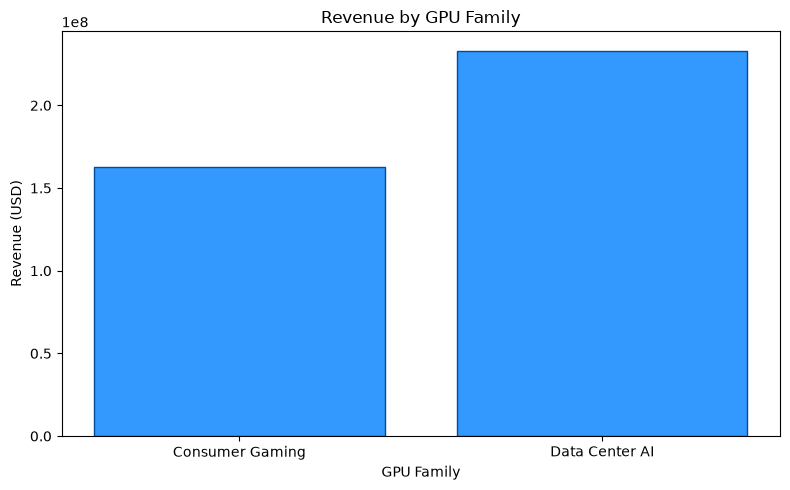

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file_path = r"C:\Users\Sakthi\Data Visualization Techniques\nvidia_gpu_sales_synthetic_2026.csv"
df = pd.read_csv(file_path)

# Aggregate total revenue by GPU Family
family_revenue = df.groupby('gpu_family')['revenue_usd'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(family_revenue['gpu_family'], family_revenue['revenue_usd'], color='#3399FF', edgecolor='#004C99')
plt.title('Revenue by GPU Family')
plt.xlabel('GPU Family')
plt.ylabel('Revenue (USD)')
plt.tight_layout()
plt.show()